In [2]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
filename = '/nfs/spare11/env315/data/era5_u1060_daily_1980-2019.nc'
data = xr.open_dataset(filename).compute()
data = data.u_component_of_wind
data

0
1
2
3
5


/knight/mamba_aug23/envs/aug23_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gribberish' loading failed:
No module named 'gribberish'
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


<xarray.DataArray 'u_component_of_wind' (time: 14610)>
array([33.964096, 37.398537, 38.92926 , ..., 41.941204, 40.91121 ,
       41.22743 ], dtype=float32)
Coordinates:
    lat      float64 60.0
    plev     float64 1e+03
  * time     (time) datetime64[ns] 1980-01-01T09:00:00 ... 2019-12-31T09:00:00

In [6]:
u_winter = data.sel(time=data.time.dt.month.isin([1,2,11,12]))
u_winter

<xarray.DataArray 'u_component_of_wind' (time: 4810)>
array([33.964096, 37.398537, 38.92926 , ..., 41.941204, 40.91121 ,
       41.22743 ], dtype=float32)
Coordinates:
    lat      float64 60.0
    plev     float64 1e+03
  * time     (time) datetime64[ns] 1980-01-01T09:00:00 ... 2019-12-31T09:00:00

In [22]:
from scipy.stats import norm
mu, sigma = norm.fit(u_winter)
print(mu,sigma)

z_scores = (u_winter - mu) / sigma
print(u_winter.shape)

29.169952 16.096548
(4810,)


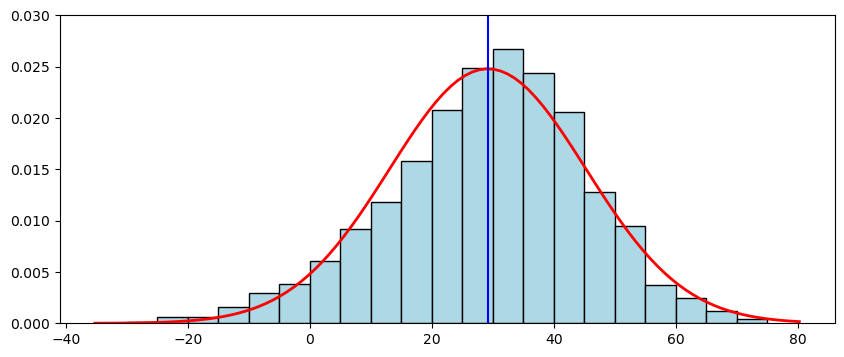

In [28]:
# Plot histogram of u_winter
fig = plt.figure(figsize=(10,4))
plt.hist(u_winter, bins=np.arange(-30, 80, 5), density=True, color='lightblue', edgecolor="black")

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, 'r', linewidth=2)

plt.vlines(np.mean(u_winter), 0, 0.030, colors='b')
plt.ylim([0,0.03])

plt.show()